In [1]:
from google.colab import files
uploaded = files.upload()

Saving soumya.txt to soumya.txt


In [2]:
with open('soumya.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [4]:
with open('soumya.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

In [5]:
chars = sorted(set(text))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for c, i in char_to_int.items()}

seq_length = 40
sequences = []
next_chars = []

for i in range(len(text) - seq_length):
    sequences.append([char_to_int[c] for c in text[i:i+seq_length]])
    next_chars.append(char_to_int[text[i+seq_length]])

sequences = np.array(sequences)
next_chars = np.array(next_chars)

X = sequences
y = to_categorical(next_chars, num_classes=len(chars))


In [6]:
model = Sequential([
    Embedding(input_dim=len(chars), output_dim=50, input_length=seq_length),
    SimpleRNN(128, return_sequences=False),
    Dense(len(chars), activation="softmax")
])

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Training in stages
model.fit(X, y, epochs=10, batch_size=64)
model.fit(X, y, epochs=20, batch_size=64)
model.fit(X, y, epochs=30, batch_size=64)
model.fit(X, y, epochs=40, batch_size=64)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1158 - loss: 3.2928
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.1808 - loss: 2.9865
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2476 - loss: 2.7228
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2946 - loss: 2.5210
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3116 - loss: 2.3837
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3225 - loss: 2.2958
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3439 - loss: 2.2347
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3609 - loss: 2.1782
Epoch 9/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3813 - loss: 2.1176
Epoch 10/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3886 - loss: 2.0684
Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4023 - loss: 1.9883
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0

174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Accuracy: 0.9171180931744312

Classification Report:

              precision    recall  f1-score   support

           
       0.99      0.96      0.97       137
                   0.95      0.96      0.96       823
           "       1.00      1.00      1.00         4
           ,       0.90      0.87      0.89        63
           -       0.75      0.86      0.80         7
           .       0.84      0.89      0.87       121
           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5
           2       0.88      1.00      0.93         7
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       0.67      1.00      0.80         2
           6       0.00      0.00      0.00         1
           7       1.00      1.00      1.00         1
           8       1.00      0.67      0.80         3
           :       1.00      1.00      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


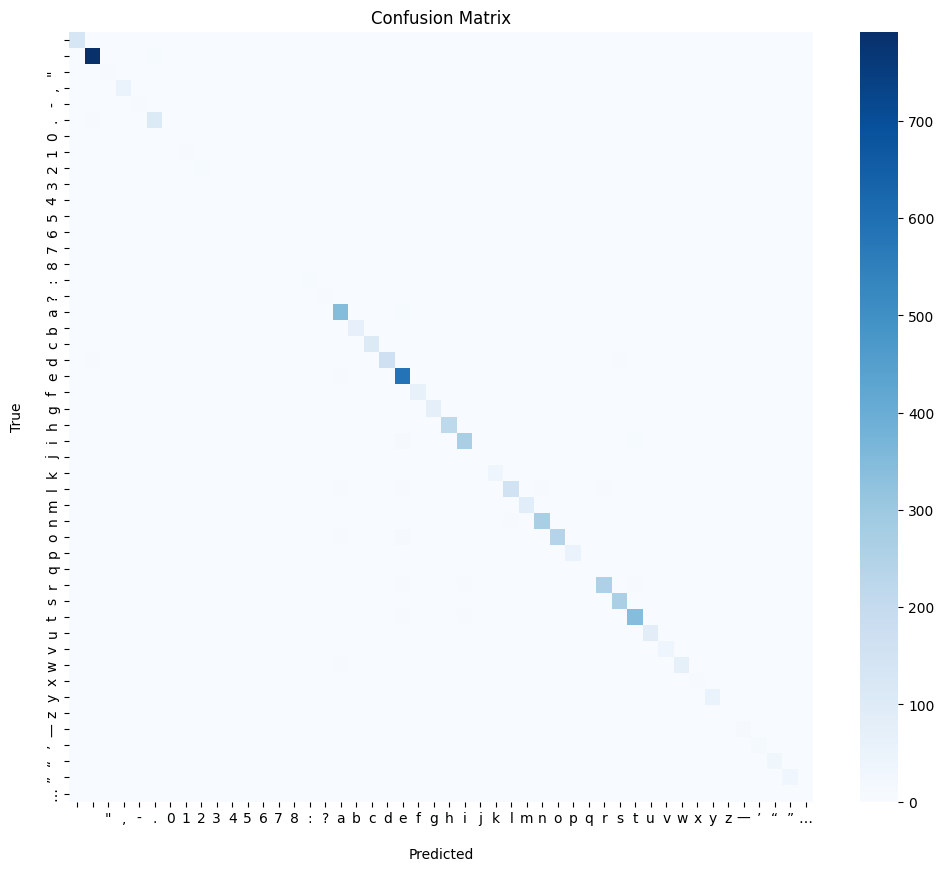

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the training data (or use X_test if you split the data)
y_pred_probs = model.predict(X)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[int_to_char[i] for i in range(len(chars))]))

# Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)

# Plotting Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap="Blues", xticklabels=chars, yticklabels=chars, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [8]:
def generate_text(seed_text, length=200):
    result = seed_text
    for _ in range(length):
        input_seq = [char_to_int.get(char, 0) for char in seed_text[-seq_length:]]
        # Pad the input sequence if it's shorter than seq_length
        input_seq = pad_sequences([input_seq], maxlen=seq_length, padding='pre')[0]
        input_seq = np.array(input_seq).reshape(1, seq_length)
        predicted_index = np.argmax(model.predict(input_seq, verbose=0))
        predicted_char = int_to_char[predicted_index]
        result += predicted_char
        seed_text += predicted_char
    return result

In [9]:
seed_text = "in the year 2146, earth was silent."
generated = generate_text(seed_text, length=200)
print("\nGenerated Text:\n", generated)


Generated Text:
 in the year 2146, earth was silent.

the once blue planet, homes ware in throe pacleve?”

“in the erked in ackone. suedard they wore.

the are fir erath woremmer earthils.

chopte rat mence. sulding wo abried bele. erare shal plicyilin


In [13]:
# Import necessary library for data splitting
from sklearn.model_selection import train_test_split

# ... (Your existing code for data preparation) ...

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size and random_state as needed

# Define a function to train and validate the model for different epoch counts
def train_and_validate(model, X_train, y_train, X_val, y_val, epochs):
    print(f"Training for {epochs} epochs...")
    history = model.fit(
        X_train, y_train,                      # Training data
        epochs=epochs,                         # Number of epochs
        batch_size=32,                         # Batch size
        validation_data=(X_val, y_val),        # Validation data
        validation_freq=1,                     # Run validation every epoch
        verbose=1                               # Show training progress
    )
    return history

# Train for 10 epochs
history_10 = train_and_validate(model, X_train, y_train, X_val, y_val, 10)

# Train for 20 epochs
history_20 = train_and_validate(model, X_train, y_train, X_val, y_val, 20)

# Train for 30 epochs
history_30 = train_and_validate(model, X_train, y_train, X_val, y_val, 30)

# Train for 40 epochs
history_40 = train_and_validate(model, X_train, y_train, X_val, y_val, 40)


Training for 10 epochs...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6812 - loss: 1.0393 - val_accuracy: 0.7428 - val_loss: 0.8145
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7916 - loss: 0.6542 - val_accuracy: 0.7383 - val_loss: 0.8043
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8520 - loss: 0.4567 - val_accuracy: 0.7617 - val_loss: 0.7492
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8956 - loss: 0.3588 - val_accuracy: 0.7717 - val_loss: 0.7157
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9278 - loss: 0.2889 - val_accuracy: 0.7825 - val_loss: 0.6864
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9298 - loss: 0.2808 - val_accuracy: 0.7347 - val_loss: 0.7901
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9321 - loss: 0.2850 - val_accuracy: 0.7428 - val_loss: 0.7526
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9544

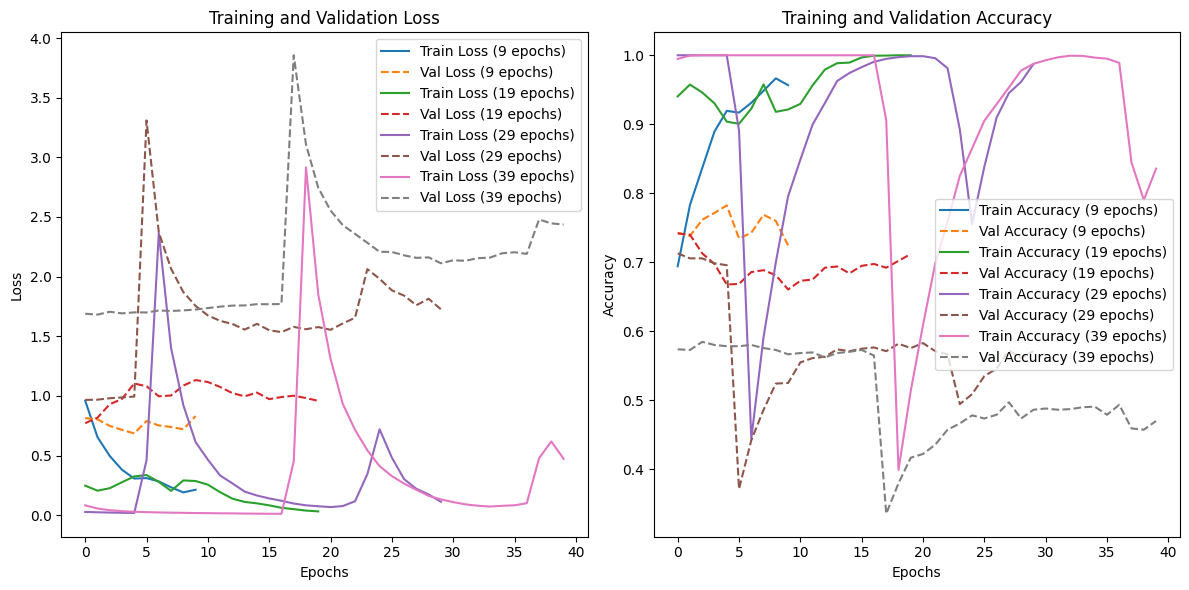

In [14]:
import matplotlib.pyplot as plt

# Function to plot training and validation loss and accuracy
def plot_training_history(histories):
    plt.figure(figsize=(12, 6))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    for history in histories:
        plt.plot(history.history['loss'], label=f'Train Loss ({history.epoch[-1]} epochs)')
        plt.plot(history.history['val_loss'], label=f'Val Loss ({history.epoch[-1]} epochs)', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    for history in histories:
        plt.plot(history.history['accuracy'], label=f'Train Accuracy ({history.epoch[-1]} epochs)')
        plt.plot(history.history['val_accuracy'], label=f'Val Accuracy ({history.epoch[-1]} epochs)', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combine all histories (for 10, 20, 30, 40 epochs)
histories = [history_10, history_20, history_30, history_40]

# Plot the results
plot_training_history(histories)
